In [1]:
## This code cell is for the initial setup: imports, config, data transformations logic ##
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim

# Device Configuration
hw_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data Transformations
img_pipeline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [9]:
##This code cell is for loading the full CIFAR-10 dataset and spliting it up into training and testing sets
## Note* since using the full dataset tasks too long I have defaulted to using 2 training batches and 1 validation batch *

cifar_train_all = datasets.CIFAR10(root='./data', train=True, download=True, transform=img_pipeline)

cifar_test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=img_pipeline)

# Here we subset the Data (2 batches for train, 1 batch for validation)
idx_for_training = list(range(0, 20000))
idx_for_validation = list(range(20000, 30000))

cifar_train_subset = Subset(cifar_train_all, idx_for_training)
cifar_val_subset = Subset(cifar_train_all, idx_for_validation)

100%|██████████| 170M/170M [00:04<00:00, 42.1MB/s]


In [10]:
# In this code cell were setting up the data loaders and defineing the batch size - 250

BATCH_SIZE_CONFIG = 250

loader_for_train = DataLoader(cifar_train_subset, batch_size=BATCH_SIZE_CONFIG, shuffle=True)
loader_for_val = DataLoader(cifar_val_subset, batch_size=BATCH_SIZE_CONFIG, shuffle=False)
loader_for_test = DataLoader(cifar_test_data, batch_size=BATCH_SIZE_CONFIG, shuffle=False)

print(f"Total training samples loaded: {len(cifar_train_subset)}")
print(f"Total validation samples loaded: {len(cifar_val_subset)}")
print(f"Total testing samples loaded: {len(cifar_test_data)}")

Total training samples loaded: 20000
Total validation samples loaded: 10000
Total testing samples loaded: 10000


In [11]:
#In this code cell I built a network that can accept variable parameters: input_size, hidden_size,num_hidden_layers, etc.
#It flattens the image dynamically inside the forward pass, and has a loop to generate multiple hidden layers and inserts a dropout layer if the rate is greater than 0.


class DynamicFeedforwardNN(nn.Module):
    def __init__(self, in_dim, hid_dim, out_classes, num_hid_layers, drop_prob=0.0):
        super(DynamicFeedforwardNN, self).__init__()
        self.network_layers = nn.ModuleList()

        # Default hidden layer
        self.network_layers.append(nn.Linear(in_dim, hid_dim))
        self.network_layers.append(nn.Sigmoid())
        if drop_prob > 0.0:
            self.network_layers.append(nn.Dropout(drop_prob))

        # Adds hidden layers if num_hidden_layers > 1
        for _ in range(num_hid_layers - 1):
            self.network_layers.append(nn.Linear(hid_dim, hid_dim))
            self.network_layers.append(nn.Sigmoid())
            if drop_prob > 0.0:
                self.network_layers.append(nn.Dropout(drop_prob))

        self.final_out = nn.Linear(hid_dim, out_classes)

    # This is where we flatten the image to fit inside the forward pass.
    def forward(self, img_tensor):
        flat_img = img_tensor.view(-1, 32 * 32 * 3)

        for current_layer in self.network_layers:
            flat_img = current_layer(flat_img)

        return self.final_out(flat_img)

In [12]:
#In this code cell I'm defining two initialization methods for parameter weights, and parameter bias.

def zero_weight_init(neural_net_layer):
    if isinstance(neural_net_layer, nn.Linear):
        nn.init.zeros_(neural_net_layer.weight)
        nn.init.zeros_(neural_net_layer.bias)

def random_weight_init(neural_net_layer):
    if isinstance(neural_net_layer, nn.Linear):
        nn.init.uniform_(neural_net_layer.weight, a=-0.05, b=0.05)
        nn.init.zeros_(neural_net_layer.bias)

In [13]:
#In this code cell we define the tarin and evaluation method.
def fit_and_validate_model(model, learning_rate, total_eps):
    loss_fn = nn.CrossEntropyLoss()
    optim_algo = optim.SGD(model.parameters(), lr=learning_rate)

    trn_err_history = []
    tst_err_history = []

    for current_ep in range(total_eps):
        model.train()
        trn_correct_preds = 0
        trn_total_samples = 0

        for inputs, targets in loader_for_train:
            inputs, targets = inputs.to(hw_device), targets.to(hw_device)

            # Forward pass
            predictions = model(inputs)
            batch_loss = loss_fn(predictions, targets)

            # Backward and optimize
            optim_algo.zero_grad()
            batch_loss.backward()
            optim_algo.step()

            # Training accuracy
            _, preds_max = torch.max(predictions.data, 1)
            trn_total_samples += targets.size(0)
            trn_correct_preds += (preds_max == targets).sum().item()

        # Calculating the training error rate
        ep_train_err = 1.0 - (trn_correct_preds / trn_total_samples)
        trn_err_history.append(ep_train_err)

        # Evaluation Phase
        model.eval()
        tst_correct_preds = 0
        tst_total_samples = 0

        with torch.no_grad():
            for inputs, targets in loader_for_test:
                inputs, targets = inputs.to(hw_device), targets.to(hw_device)
                predictions = model(inputs)
                _, preds_max = torch.max(predictions.data, 1)
                tst_total_samples += targets.size(0)
                tst_correct_preds += (preds_max == targets).sum().item()

        # Calculating testing error rate
        ep_test_err = 1.0 - (tst_correct_preds / tst_total_samples)
        tst_err_history.append(ep_test_err)

        print(f">>> Ep [{current_ep+1}/{total_eps}] : Trn Err = {ep_train_err:.4f} | Tst Err = {ep_test_err:.4f}")

    return trn_err_history, tst_err_history

>>> Ep [1/15] : Trn Err = 0.8639 | Tst Err = 0.8224
>>> Ep [2/15] : Trn Err = 0.8015 | Tst Err = 0.7659
>>> Ep [3/15] : Trn Err = 0.7733 | Tst Err = 0.7541
>>> Ep [4/15] : Trn Err = 0.7600 | Tst Err = 0.7494
>>> Ep [5/15] : Trn Err = 0.7520 | Tst Err = 0.7495
>>> Ep [6/15] : Trn Err = 0.7455 | Tst Err = 0.7305
>>> Ep [7/15] : Trn Err = 0.7331 | Tst Err = 0.7261
>>> Ep [8/15] : Trn Err = 0.7306 | Tst Err = 0.7126
>>> Ep [9/15] : Trn Err = 0.7209 | Tst Err = 0.7145
>>> Ep [10/15] : Trn Err = 0.7162 | Tst Err = 0.7082
>>> Ep [11/15] : Trn Err = 0.7124 | Tst Err = 0.7051
>>> Ep [12/15] : Trn Err = 0.7070 | Tst Err = 0.7037
>>> Ep [13/15] : Trn Err = 0.7056 | Tst Err = 0.6935
>>> Ep [14/15] : Trn Err = 0.6977 | Tst Err = 0.6928
>>> Ep [15/15] : Trn Err = 0.6943 | Tst Err = 0.6892


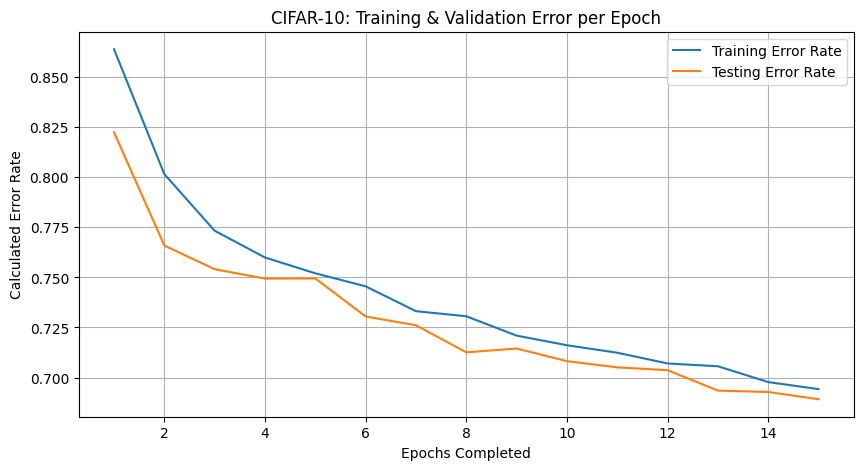

In [14]:
# In this code cell we are showing the model performance with the basline parameters.
DIM_INPUT = 32 * 32 * 3
DIM_HIDDEN = 100
CLASSES_NUM = 10
LAYERS_NUM = 1
DROP_PROB = 0.0
LR_RATE = 0.01
TOTAL_EPOCHS = 15

baseline_model = DynamicFeedforwardNN(DIM_INPUT, DIM_HIDDEN, CLASSES_NUM, LAYERS_NUM, DROP_PROB).to(hw_device)
baseline_model.apply(random_weight_init)

history_train_err, history_test_err = fit_and_validate_model(baseline_model, LR_RATE, TOTAL_EPOCHS)

plt.figure(figsize=(10, 5))
plt.plot(range(1, TOTAL_EPOCHS + 1), history_train_err, label='Training Error Rate')
plt.plot(range(1, TOTAL_EPOCHS + 1), history_test_err, label='Testing Error Rate')
plt.xlabel('Epochs Completed')
plt.ylabel('Calculated Error Rate')
plt.title('CIFAR-10: Training & Validation Error per Epoch')
plt.legend()
plt.grid(True)
plt.show()

>>> Preparing architecture for epoch sweep analysis...
>>> Executing training over 30 iterations...
>>> Ep [1/30] : Trn Err = 0.8629 | Tst Err = 0.8121
>>> Ep [2/30] : Trn Err = 0.7917 | Tst Err = 0.7850
>>> Ep [3/30] : Trn Err = 0.7785 | Tst Err = 0.7637
>>> Ep [4/30] : Trn Err = 0.7642 | Tst Err = 0.7479
>>> Ep [5/30] : Trn Err = 0.7528 | Tst Err = 0.7423
>>> Ep [6/30] : Trn Err = 0.7420 | Tst Err = 0.7340
>>> Ep [7/30] : Trn Err = 0.7331 | Tst Err = 0.7263
>>> Ep [8/30] : Trn Err = 0.7273 | Tst Err = 0.7193
>>> Ep [9/30] : Trn Err = 0.7228 | Tst Err = 0.7122
>>> Ep [10/30] : Trn Err = 0.7162 | Tst Err = 0.7079
>>> Ep [11/30] : Trn Err = 0.7130 | Tst Err = 0.7049
>>> Ep [12/30] : Trn Err = 0.7080 | Tst Err = 0.6991
>>> Ep [13/30] : Trn Err = 0.7063 | Tst Err = 0.6958
>>> Ep [14/30] : Trn Err = 0.7025 | Tst Err = 0.6970
>>> Ep [15/30] : Trn Err = 0.6996 | Tst Err = 0.6894
>>> Ep [16/30] : Trn Err = 0.6949 | Tst Err = 0.6896
>>> Ep [17/30] : Trn Err = 0.6945 | Tst Err = 0.6860
>>> Ep [

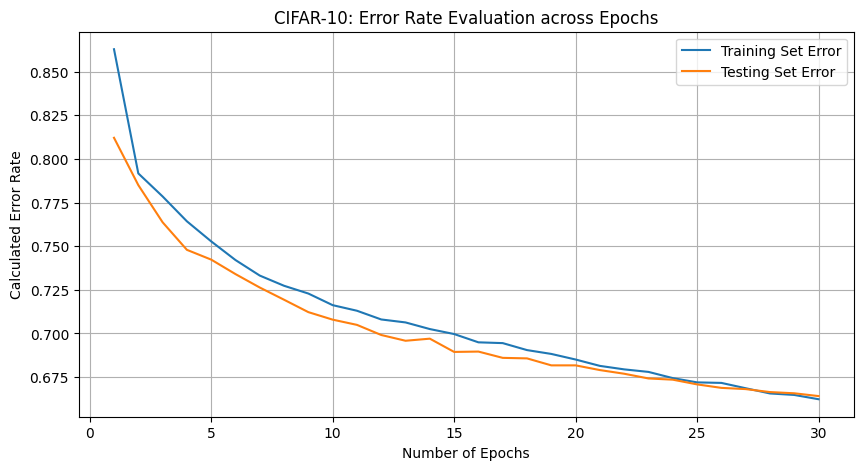

In [15]:
# In this code cell we test the impact of epochs on error rate. We'll set learning rate to 0.01 and nodes to 100
SWEEP_EPOCHS_MAX = 30
epoch_test_model = DynamicFeedforwardNN(DIM_INPUT, DIM_HIDDEN, CLASSES_NUM, LAYERS_NUM, DROP_PROB).to(hw_device)
epoch_test_model.apply(random_weight_init)

print(">>> Preparing architecture for epoch sweep analysis...")
print(f">>> Executing training over {SWEEP_EPOCHS_MAX} iterations...")
err_trn_ep, err_tst_ep = fit_and_validate_model(epoch_test_model, LR_RATE, SWEEP_EPOCHS_MAX)

plt.figure(figsize=(10, 5))
plt.plot(range(1, SWEEP_EPOCHS_MAX + 1), err_trn_ep, label='Training Set Error')
plt.plot(range(1, SWEEP_EPOCHS_MAX + 1), err_tst_ep, label='Testing Set Error')
plt.xlabel('Number of Epochs')
plt.ylabel('Calculated Error Rate')
plt.title('CIFAR-10: Error Rate Evaluation across Epochs')
plt.legend()
plt.grid(True)
plt.show()

Analysis: Error Rate vs. Epochs

Both the training and testing error rates drop off smoothly as the epochs increase, with the training error starting ~0.86 and the testing error starting lower ~0.81, before both slowly meeting at ~0.66.

The two curves track closely together throughout the entire 30 epochs, with the testing error staying slightly below the training error until they converge at the end. This shows that the model is actively learning and successfully bringing the error down from random guessing.

More importantly, because the testing error follows the training error instead of shooting back up, we can say the model isn't overfitting. However, the curve begins to flatten out around epoch 25. This slowed progress is an issue that comes from the Sigmoid activation function.  

As the nodes become saturated, the gradients shrink, which leads to small weight updates. We could let it run for 100 epochs, but it probably wouldn't improve much.

In conclusion we can say, an error rate of 0.66 means that this basic model is too simple for the complexity of the dataset, indicating that the model is currently underfitting.


>>> Evaluating architecture using 2 hidden units...
>>> Ep [1/15] : Trn Err = 0.9024 | Tst Err = 0.9089
>>> Ep [2/15] : Trn Err = 0.9025 | Tst Err = 0.9051
>>> Ep [3/15] : Trn Err = 0.8975 | Tst Err = 0.9003
>>> Ep [4/15] : Trn Err = 0.8950 | Tst Err = 0.8981
>>> Ep [5/15] : Trn Err = 0.8927 | Tst Err = 0.8967
>>> Ep [6/15] : Trn Err = 0.8885 | Tst Err = 0.8954
>>> Ep [7/15] : Trn Err = 0.8885 | Tst Err = 0.8928
>>> Ep [8/15] : Trn Err = 0.8841 | Tst Err = 0.8807
>>> Ep [9/15] : Trn Err = 0.8746 | Tst Err = 0.8708
>>> Ep [10/15] : Trn Err = 0.8646 | Tst Err = 0.8599
>>> Ep [11/15] : Trn Err = 0.8546 | Tst Err = 0.8518
>>> Ep [12/15] : Trn Err = 0.8478 | Tst Err = 0.8490
>>> Ep [13/15] : Trn Err = 0.8460 | Tst Err = 0.8451
>>> Ep [14/15] : Trn Err = 0.8400 | Tst Err = 0.8418
>>> Ep [15/15] : Trn Err = 0.8365 | Tst Err = 0.8398

>>> Evaluating architecture using 50 hidden units...
>>> Ep [1/15] : Trn Err = 0.9022 | Tst Err = 0.8782
>>> Ep [2/15] : Trn Err = 0.8312 | Tst Err = 0.7981
>>>

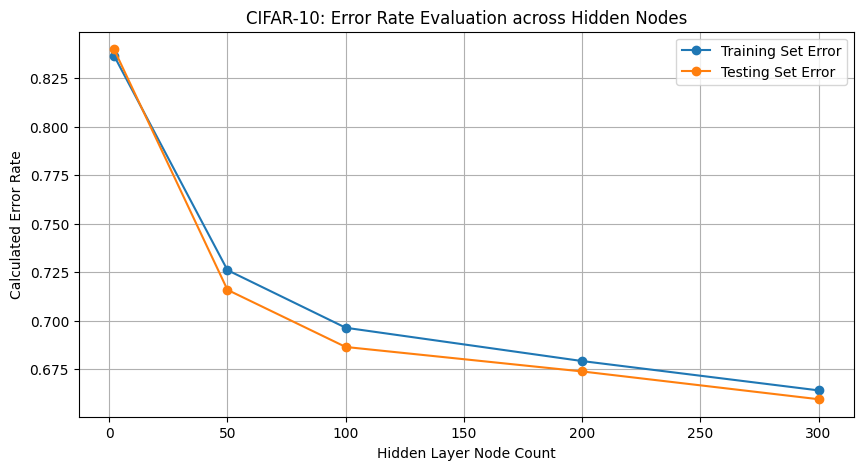

In [16]:
#In this code cell we test the impact of hidden nodes on error rate.
sweep_hid_nodes = [2, 50, 100, 200, 300]
err_trn_nodes = []
err_tst_nodes = []

for node_count in sweep_hid_nodes:
    print(f"\n>>> Evaluating architecture using {node_count} hidden units...")
    node_sweep_net = DynamicFeedforwardNN(DIM_INPUT, node_count, CLASSES_NUM, LAYERS_NUM, DROP_PROB).to(hw_device)
    node_sweep_net.apply(random_weight_init)

    err_trn, err_tst = fit_and_validate_model(node_sweep_net, LR_RATE, TOTAL_EPOCHS)

    err_trn_nodes.append(err_trn[-1])
    err_tst_nodes.append(err_tst[-1])

plt.figure(figsize=(10, 5))
plt.plot(sweep_hid_nodes, err_trn_nodes, marker='o', label='Training Set Error')
plt.plot(sweep_hid_nodes, err_tst_nodes, marker='o', label='Testing Set Error')
plt.xlabel('Hidden Layer Node Count')
plt.ylabel('Calculated Error Rate')
plt.title('CIFAR-10: Error Rate Evaluation across Hidden Nodes')
plt.legend()
plt.grid(True)
plt.show()

Analysis: Error Rate vs. Hidden Node Count

This plot shows how the model's performance scales as we increase the number of nodes in the hidden layer.

Initially, with very few nodes, both training and testing error rates are high, starting ~0.84. As we increase the hidden layer to 50 and then 100 nodes, we see a steep drop in the error rate, showing that the added capacity enables the model to learn the data much more effectively. After 100 nodes, the improvement slows down, gradually decreasing to an error rate of ~0.66 at 300 nodes.

The testing error curve closely tracks and remains slightly below the training error curve across all node counts. This consistent alignment tells us that adding up to 300 nodes increases the model's learning without causing it to memorize the training data and overfit.

However, since the error rate still plateaus ~0.66, This shows that our previous conclusion: simply adding more nodes to this basic model is not enough for it to properly learn a complex dataset, and the model remains underfit overall.

>>> Training with zero-initialized weights...
>>> Ep [1/15] : Trn Err = 0.8984 | Tst Err = 0.9000
>>> Ep [2/15] : Trn Err = 0.8981 | Tst Err = 0.9000
>>> Ep [3/15] : Trn Err = 0.8999 | Tst Err = 0.9000
>>> Ep [4/15] : Trn Err = 0.9016 | Tst Err = 0.9000
>>> Ep [5/15] : Trn Err = 0.8992 | Tst Err = 0.9000
>>> Ep [6/15] : Trn Err = 0.9022 | Tst Err = 0.9000
>>> Ep [7/15] : Trn Err = 0.9013 | Tst Err = 0.9000
>>> Ep [8/15] : Trn Err = 0.9030 | Tst Err = 0.9000
>>> Ep [9/15] : Trn Err = 0.8985 | Tst Err = 0.9000
>>> Ep [10/15] : Trn Err = 0.8993 | Tst Err = 0.9000
>>> Ep [11/15] : Trn Err = 0.9011 | Tst Err = 0.9000
>>> Ep [12/15] : Trn Err = 0.9023 | Tst Err = 0.9000
>>> Ep [13/15] : Trn Err = 0.9000 | Tst Err = 0.9000
>>> Ep [14/15] : Trn Err = 0.8991 | Tst Err = 0.9000
>>> Ep [15/15] : Trn Err = 0.9021 | Tst Err = 0.9000
>>> Training with random-initialized weights...
>>> Ep [1/15] : Trn Err = 0.8668 | Tst Err = 0.8317
>>> Ep [2/15] : Trn Err = 0.8131 | Tst Err = 0.7877
>>> Ep [3/15] : 

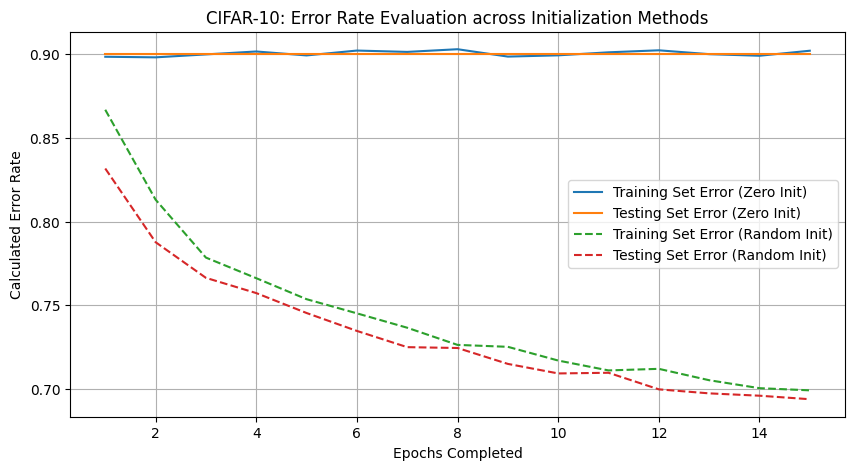

In [17]:
# In this code cell we test the impact of weight initialization on error rate. We'll set learning rate to 0.01 and epoch to 15
net_init_zero = DynamicFeedforwardNN(DIM_INPUT, DIM_HIDDEN, CLASSES_NUM, LAYERS_NUM, DROP_PROB).to(hw_device)
net_init_zero.apply(zero_weight_init)

print(">>> Training with zero-initialized weights...")
err_trn_zero, err_tst_zero = fit_and_validate_model(net_init_zero, LR_RATE, TOTAL_EPOCHS)

net_init_rand = DynamicFeedforwardNN(DIM_INPUT, DIM_HIDDEN, CLASSES_NUM, LAYERS_NUM, DROP_PROB).to(hw_device)
net_init_rand.apply(random_weight_init)

print(">>> Training with random-initialized weights...")
err_trn_rand, err_tst_rand = fit_and_validate_model(net_init_rand, LR_RATE, TOTAL_EPOCHS)

plt.figure(figsize=(10, 5))
plt.plot(range(1, TOTAL_EPOCHS + 1), err_trn_zero, label='Training Set Error (Zero Init)')
plt.plot(range(1, TOTAL_EPOCHS + 1), err_tst_zero, label='Testing Set Error (Zero Init)')
plt.plot(range(1, TOTAL_EPOCHS + 1), err_trn_rand, label='Training Set Error (Random Init)', linestyle='--')
plt.plot(range(1, TOTAL_EPOCHS + 1), err_tst_rand, label='Testing Set Error (Random Init)', linestyle='--')
plt.xlabel('Epochs Completed')
plt.ylabel('Calculated Error Rate')
plt.title('CIFAR-10: Error Rate Evaluation across Initialization Methods')
plt.legend()
plt.grid(True)
plt.show()

Analysis: Error Rate vs. Initialization Methods

This plot shows the how we initialize weights in a neural network by comparing Zero Initialization against Random Initializatio.

The curves for Zero Initialization remain completely flat at an error rate of 0.90 for both training and testing. This means the model is doing nothing but randomly guessing. This clearly shows the symmetry problem; if all weights start at zero, every node in a hidden layer computes the same output and receives the exact same gradient update. Because they all update the same, the network fails to learn distinct features and stays stuck.

On the other hand, the Random Initialization curves show a steady decline. By starting the weights at small, random values, we solve the issue, allowing different nodes to learn different patterns in the images. The error drops from  ~0.87 down to ~0.70, with the testing error once again tracking alongside the training error. This shows that the model is learning without overfitting.


>>> Model training with LR = 0.0005...
>>> Ep [1/15] : Trn Err = 0.8847 | Tst Err = 0.8760
>>> Ep [2/15] : Trn Err = 0.8803 | Tst Err = 0.8718
>>> Ep [3/15] : Trn Err = 0.8768 | Tst Err = 0.8691
>>> Ep [4/15] : Trn Err = 0.8728 | Tst Err = 0.8650
>>> Ep [5/15] : Trn Err = 0.8694 | Tst Err = 0.8621
>>> Ep [6/15] : Trn Err = 0.8663 | Tst Err = 0.8594
>>> Ep [7/15] : Trn Err = 0.8633 | Tst Err = 0.8543
>>> Ep [8/15] : Trn Err = 0.8607 | Tst Err = 0.8509
>>> Ep [9/15] : Trn Err = 0.8550 | Tst Err = 0.8458
>>> Ep [10/15] : Trn Err = 0.8507 | Tst Err = 0.8423
>>> Ep [11/15] : Trn Err = 0.8457 | Tst Err = 0.8360
>>> Ep [12/15] : Trn Err = 0.8405 | Tst Err = 0.8316
>>> Ep [13/15] : Trn Err = 0.8367 | Tst Err = 0.8279
>>> Ep [14/15] : Trn Err = 0.8343 | Tst Err = 0.8248
>>> Ep [15/15] : Trn Err = 0.8301 | Tst Err = 0.8207

>>> Model training with LR = 0.001...
>>> Ep [1/15] : Trn Err = 0.9086 | Tst Err = 0.9103
>>> Ep [2/15] : Trn Err = 0.9064 | Tst Err = 0.9035
>>> Ep [3/15] : Trn Err = 0.900

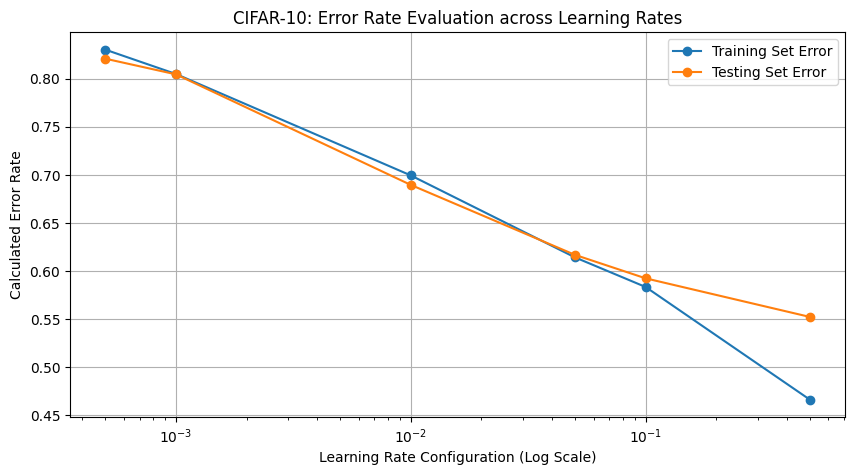

In [18]:
#In this code cell we test the impact of learning rate on error rate.
sweep_learning_rates = [0.0005, 0.001, 0.01, 0.05, 0.1, 0.5]
err_trn_lr = []
err_tst_lr = []

for current_lr in sweep_learning_rates:
    print(f"\n>>> Model training with LR = {current_lr}...")
    net_lr_sweep = DynamicFeedforwardNN(DIM_INPUT, DIM_HIDDEN, CLASSES_NUM, LAYERS_NUM, DROP_PROB).to(hw_device)
    net_lr_sweep.apply(random_weight_init)

    err_trn, err_tst = fit_and_validate_model(net_lr_sweep, current_lr, TOTAL_EPOCHS)

    err_trn_lr.append(err_trn[-1])
    err_tst_lr.append(err_tst[-1])

plt.figure(figsize=(10, 5))
plt.plot(sweep_learning_rates, err_trn_lr, marker='o', label='Training Set Error')
plt.plot(sweep_learning_rates, err_tst_lr, marker='o', label='Testing Set Error')
plt.xscale('log')
plt.xlabel('Learning Rate Configuration (Log Scale)')
plt.ylabel('Calculated Error Rate')
plt.title('CIFAR-10: Error Rate Evaluation across Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

Analysis: Error Rate vs. Learning Rates

This plot shows the relationship between the learning rate and the resulting error after training. We can see a strong downward trend; as the learning rate increases from $10^{-3}$ to $10^{-1}$ and beyond, the final error rate drops significantly.

At a very low learning rate ($10^{-3}$), the model is taking steps that are too small to reach an optimal solution within the training time, which results in a high error of ~0.85.

As the learning rate increases, the model converges, reaching its lowest error of ~0.46 (training) and ~0.55 (testing). We can see that as we reach the highest learning rate on the right, there's a gap between the training and testing sets. While the training error continues to go down, the testing error does not follow it. This shows that ist slowly begining to overfit, and the model starts to memorize the specific patterns of the training data rather than learning general patterns. This learning rate is the highest we got, but it indicates that tthe model is reaching its limit to learning general patterns.


>>> Training architecture with 1 hidden layer(s)...
>>> Ep [1/15] : Trn Err = 0.8752 | Tst Err = 0.8135
>>> Ep [2/15] : Trn Err = 0.8001 | Tst Err = 0.7714
>>> Ep [3/15] : Trn Err = 0.7743 | Tst Err = 0.7623
>>> Ep [4/15] : Trn Err = 0.7581 | Tst Err = 0.7611
>>> Ep [5/15] : Trn Err = 0.7531 | Tst Err = 0.7458
>>> Ep [6/15] : Trn Err = 0.7444 | Tst Err = 0.7382
>>> Ep [7/15] : Trn Err = 0.7355 | Tst Err = 0.7264
>>> Ep [8/15] : Trn Err = 0.7290 | Tst Err = 0.7215
>>> Ep [9/15] : Trn Err = 0.7240 | Tst Err = 0.7149
>>> Ep [10/15] : Trn Err = 0.7176 | Tst Err = 0.7129
>>> Ep [11/15] : Trn Err = 0.7151 | Tst Err = 0.7097
>>> Ep [12/15] : Trn Err = 0.7101 | Tst Err = 0.7079
>>> Ep [13/15] : Trn Err = 0.7063 | Tst Err = 0.7018
>>> Ep [14/15] : Trn Err = 0.7041 | Tst Err = 0.6966
>>> Ep [15/15] : Trn Err = 0.7000 | Tst Err = 0.6994

>>> Training architecture with 2 hidden layer(s)...
>>> Ep [1/15] : Trn Err = 0.8963 | Tst Err = 0.9003
>>> Ep [2/15] : Trn Err = 0.8995 | Tst Err = 0.9024
>>> 

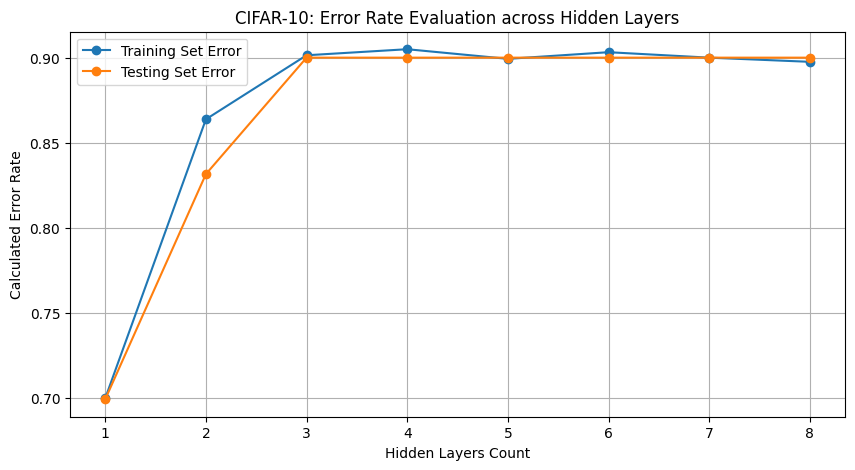

In [19]:
# In this code cell we test the impact of number of hidden layers on error rate.
sweep_hidden_layers = [1, 2, 3, 4, 5, 6, 7, 8]
err_trn_layers = []
err_tst_layers = []

for num_layers in sweep_hidden_layers:
    print(f"\n>>> Training model with {num_layers} hidden layer(s)...")
    net_layer_sweep = DynamicFeedforwardNN(DIM_INPUT, DIM_HIDDEN, CLASSES_NUM, num_layers, DROP_PROB).to(hw_device)
    net_layer_sweep.apply(random_weight_init)

    err_trn, err_tst = fit_and_validate_model(net_layer_sweep, LR_RATE, TOTAL_EPOCHS)

    err_trn_layers.append(err_trn[-1])
    err_tst_layers.append(err_tst[-1])

plt.figure(figsize=(10, 5))
plt.plot(sweep_hidden_layers, err_trn_layers, marker='o', label='Training Set Error')
plt.plot(sweep_hidden_layers, err_tst_layers, marker='o', label='Testing Set Error')
plt.xlabel('Hidden Layers Count')
plt.ylabel('Calculated Error Rate')
plt.title('CIFAR-10: Error Rate Evaluation across Hidden Layers')
plt.legend()
plt.grid(True)
plt.show()

Analysis: Error Rate vs. Hidden Layers

This plot shows a steep decline in model performance as the number of hidden layers increases.

While a single hidden layer gets our baseline error rate of 0.70, adding a second layer causes the error to go to over 0.85, and by three layers, the model hits a plateau at ~0.90. This 90% error rate indicates the model is completely unable to learn and is just randomly guessing

This is an example of the vanishing gradient problem, which happens when using the Sigmoid activation function in deeper networks. When the gradients are backpropagated through each layer, they are multiplied by small values from the Sigmoid derivatives, eventually becoming so small that the weights in the earliest layers stop updating.


>>> Training phase with Dropout Probability = 0.2...
>>> Ep [1/15] : Trn Err = 0.8785 | Tst Err = 0.8107
>>> Ep [2/15] : Trn Err = 0.8276 | Tst Err = 0.7811
>>> Ep [3/15] : Trn Err = 0.8042 | Tst Err = 0.7646
>>> Ep [4/15] : Trn Err = 0.7829 | Tst Err = 0.7460
>>> Ep [5/15] : Trn Err = 0.7701 | Tst Err = 0.7372
>>> Ep [6/15] : Trn Err = 0.7648 | Tst Err = 0.7258
>>> Ep [7/15] : Trn Err = 0.7542 | Tst Err = 0.7236
>>> Ep [8/15] : Trn Err = 0.7484 | Tst Err = 0.7180
>>> Ep [9/15] : Trn Err = 0.7357 | Tst Err = 0.7120
>>> Ep [10/15] : Trn Err = 0.7317 | Tst Err = 0.7113
>>> Ep [11/15] : Trn Err = 0.7291 | Tst Err = 0.7058
>>> Ep [12/15] : Trn Err = 0.7225 | Tst Err = 0.7053
>>> Ep [13/15] : Trn Err = 0.7209 | Tst Err = 0.7016
>>> Ep [14/15] : Trn Err = 0.7153 | Tst Err = 0.6969
>>> Ep [15/15] : Trn Err = 0.7156 | Tst Err = 0.6930

>>> Training phase with Dropout Probability = 0.3...
>>> Ep [1/15] : Trn Err = 0.8810 | Tst Err = 0.8191
>>> Ep [2/15] : Trn Err = 0.8357 | Tst Err = 0.7780
>>

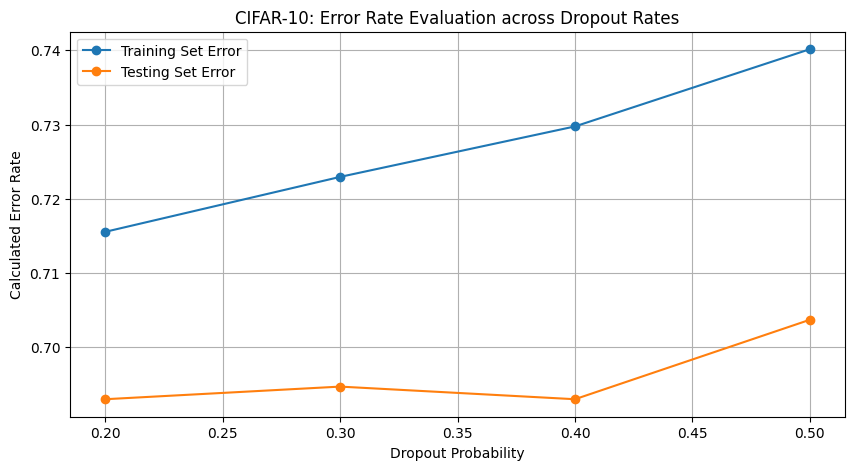

In [22]:
# In this code cell we test the impact of dropout on error rate.
sweep_drop_probs = [0.2, 0.3, 0.4, 0.5]
err_trn_drop = []
err_tst_drop = []

for current_drop_prob in sweep_drop_probs:
    print(f"\n>>> Training phase with Dropout Probability = {current_drop_prob}...")
    net_drop_sweep = DynamicFeedforwardNN(DIM_INPUT, DIM_HIDDEN, CLASSES_NUM, LAYERS_NUM, current_drop_prob).to(hw_device)
    net_drop_sweep.apply(random_weight_init)

    err_trn, err_tst = fit_and_validate_model(net_drop_sweep, LR_RATE, TOTAL_EPOCHS)

    err_trn_drop.append(err_trn[-1])
    err_tst_drop.append(err_tst[-1])

plt.figure(figsize=(10, 5))
plt.plot(sweep_drop_probs, err_trn_drop, marker='o', label='Training Set Error')
plt.plot(sweep_drop_probs, err_tst_drop, marker='o', label='Testing Set Error')
plt.xlabel('Dropout Probability')
plt.ylabel('Calculated Error Rate')
plt.title('CIFAR-10: Error Rate Evaluation across Dropout Rates')
plt.legend()
plt.grid(True)
plt.show()

Analysis: Error Rate vs. Dropout Rates

In this plot, we can see a gap where the training error is consistently higher than the testing error.

As the dropout probability increases from 0.2 to 0.5, the training error goes up steadily from ~0.715 to 0.740. This happens because dropout randomly shuts off a bunch of neurons during each training step, forcing the network to learn redundant representations and making the training harder on model.

However, the testing error stays lower and relatively stable, hovering between 0.69 and 0.70. This is because, during testing, all neurons are active the model can operate at full capacity.

The fact that the testing error doesn't go up as fast as the training error indicates that the dropout is helping the model generalize. While dropout helps close the generalization gap, the overall error rate remains high, and this confirms that the model's bottleneck is beacuse of its simple architecture.

>>> Training MGD with ReLU...
>>> Ep [1/30] : Trn Err = 0.7179 | Tst Err = 0.6093
>>> Ep [2/30] : Trn Err = 0.6634 | Tst Err = 0.6344
>>> Ep [3/30] : Trn Err = 0.6443 | Tst Err = 0.6154
>>> Ep [4/30] : Trn Err = 0.6178 | Tst Err = 0.6441
>>> Ep [5/30] : Trn Err = 0.6069 | Tst Err = 0.5898
>>> Ep [6/30] : Trn Err = 0.5968 | Tst Err = 0.5871
>>> Ep [7/30] : Trn Err = 0.5753 | Tst Err = 0.6116
>>> Ep [8/30] : Trn Err = 0.5665 | Tst Err = 0.5921
>>> Ep [9/30] : Trn Err = 0.5600 | Tst Err = 0.5535
>>> Ep [10/30] : Trn Err = 0.5474 | Tst Err = 0.6223
>>> Ep [11/30] : Trn Err = 0.5369 | Tst Err = 0.5561
>>> Ep [12/30] : Trn Err = 0.5329 | Tst Err = 0.5816
>>> Ep [13/30] : Trn Err = 0.5126 | Tst Err = 0.5829
>>> Ep [14/30] : Trn Err = 0.5154 | Tst Err = 0.5818
>>> Ep [15/30] : Trn Err = 0.5056 | Tst Err = 0.5421
>>> Ep [16/30] : Trn Err = 0.4875 | Tst Err = 0.5493
>>> Ep [17/30] : Trn Err = 0.4976 | Tst Err = 0.5350
>>> Ep [18/30] : Trn Err = 0.4843 | Tst Err = 0.5421
>>> Ep [19/30] : Trn Err 

,Metric,Training Set,Testing Set
0,Error Rate,0.3346,0.5545
1,F-Measure,0.6669,0.4412


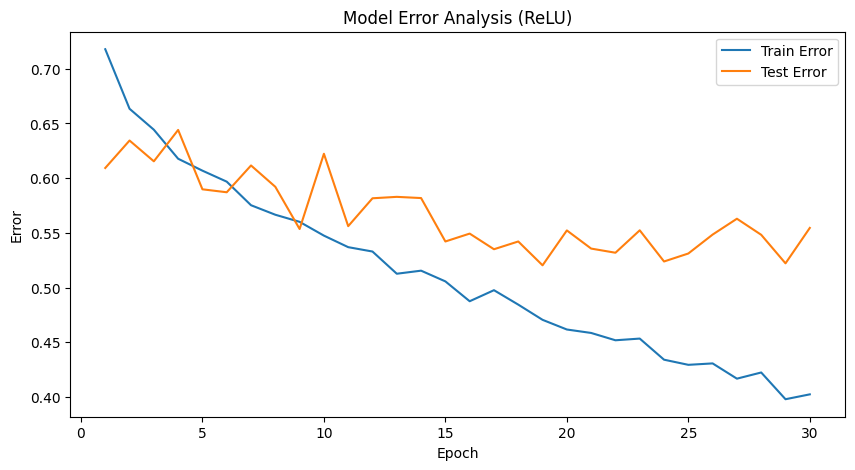

In [23]:
# In this code cell we are setting up the ReLU architecture and F-Measure stats

from sklearn.metrics import f1_score
import numpy as np

# best params from part 1
BEST_HIDDEN = 300
BEST_LAYERS = 1
BEST_LR = 0.5
BEST_EPOCHS = 30
BEST_DROPOUT = 0.4

class RefactoredReluModel(nn.Module):
    def __init__(self, in_dim, hid_dim, out_classes, num_hid_layers, drop_rate):
        super(RefactoredReluModel, self).__init__()
        self.hidden_block = nn.ModuleList()
        self.hidden_block.append(nn.Linear(in_dim, hid_dim))
        for _ in range(num_hid_layers - 1):
            self.hidden_block.append(nn.Linear(hid_dim, hid_dim))
        self.dropout_layer = nn.Dropout(drop_rate)
        self.output_layer = nn.Linear(hid_dim, out_classes)

    def forward(self, input_tensor):
        val = input_tensor.view(-1, 32 * 32 * 3)
        for layer in self.hidden_block:
            val = F.relu(layer(val))
            val = self.dropout_layer(val)
        return self.output_layer(val)

def get_performance_stats(net_model, data_iterator):
    net_model.eval()
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for items, targets in data_iterator:
            items = items.to(hw_device)
            outputs = net_model(items)
            _, predicted = torch.max(outputs.data, 1)
            all_targets.extend(targets.numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = np.mean(np.array(all_targets) == np.array(all_predictions))
    err_rate = 1.0 - accuracy
    f1 = f1_score(all_targets, all_predictions, average='macro')
    return err_rate, f1

relu_final_net = RefactoredReluModel(DIM_INPUT, BEST_HIDDEN, CLASSES_NUM, BEST_LAYERS, BEST_DROPOUT).to(hw_device)
relu_final_net.apply(random_weight_init)

print(">>> Training MGD with ReLU...")
relu_trn_history, relu_tst_history = fit_and_validate_model(relu_final_net, BEST_LR, BEST_EPOCHS)

train_err, train_f1 = get_performance_stats(relu_final_net, loader_for_train)
test_err, test_f1 = get_performance_stats(relu_final_net, loader_for_test)
stats_data = {
    "Metric": ["Error Rate", "F-Measure"],
    "Training Set": [f"{train_err:.4f}", f"{train_f1:.4f}"],
    "Testing Set": [f"{test_err:.4f}", f"{test_f1:.4f}"]
}
display(pd.DataFrame(stats_data))

plt.figure(figsize=(10, 5))
plt.plot(range(1, BEST_EPOCHS + 1), relu_trn_history, label='Train Error')
plt.plot(range(1, BEST_EPOCHS + 1), relu_tst_history, label='Test Error')
plt.title('Model Error Analysis (ReLU)')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.legend()
plt.show()

Analysis: Error Rate vs. Epochs (ReLU Activation)

This ReLU-based architecture shows a much more sustained drop in training error.

The training error goes down from ~0.73 to ~0.40 over 30 epochs. This tells us that ReLU solves the vanishing gradient problem that our previous model had using Sigmoid, and gave better weight updates and learning.

However, now we have a problem of overfitting. While the training error continues declining, the testing error becomes highly volatile and plateaus ~0.55.

The wide gap between the two curves indicates that the model is not learning general features; it is memorizing the noise and details of the training set.

In [26]:
# In this code cell we are useing a train-and-validation (k-fold crossvalidation) function to optimize the parameters of the model.
from sklearn.model_selection import KFold
import time

def execute_kfold_optimization(nodes_list, lrs_list, eps_list, k_folds=5):
    full_cv_data = cifar_train_subset
    kf_splitter = KFold(n_splits=k_folds, shuffle=True, random_state=42)

    cv_summary = []
    best_v_f1 = 0
    top_config = {}

    for nodes in nodes_list:
        for rate in lrs_list:
            for total_ep in eps_list:
                print(f"\n>>> Configuration: Nodes={nodes}, LR={rate}, Epochs={total_ep}")

                f_trn_err, f_val_err, f_tst_err = [], [], []
                f_trn_f1, f_val_f1, f_tst_f1 = [], [], []

                fold_timer = time.time()

                for f_idx, (train_idx, val_idx) in enumerate(kf_splitter.split(full_cv_data)):
                    fold_train = Subset(full_cv_data, train_idx)
                    fold_val = Subset(full_cv_data, val_idx)

                    bgd_loader = DataLoader(fold_train, batch_size=len(fold_train), shuffle=True)
                    val_loader_fold = DataLoader(fold_val, batch_size=len(fold_val), shuffle=False)

                    cv_net = RefactoredReluModel(DIM_INPUT, nodes, CLASSES_NUM, BEST_LAYERS, BEST_DROPOUT).to(hw_device)
                    cv_net.apply(random_weight_init)

                    loss_criterion = nn.CrossEntropyLoss()
                    bgd_optimizer = optim.SGD(cv_net.parameters(), lr=rate)

                    for _ in range(total_ep):
                        cv_net.train()
                        for x_bgd, y_bgd in bgd_loader:
                            x_bgd, y_bgd = x_bgd.to(hw_device), y_bgd.to(hw_device)
                            bgd_optimizer.zero_grad()
                            bgd_out = cv_net(x_bgd)
                            bgd_loss = loss_criterion(bgd_out, y_bgd)
                            bgd_loss.backward()
                            bgd_optimizer.step()

                    t_err, t_f1 = get_performance_stats(cv_net, bgd_loader)
                    v_err, v_f1 = get_performance_stats(cv_net, val_loader_fold)
                    te_err, te_f1 = get_performance_stats(cv_net, loader_for_test)

                    f_trn_err.append(t_err); f_val_err.append(v_err); f_tst_err.append(te_err)
                    f_trn_f1.append(t_f1); f_val_f1.append(v_f1); f_tst_f1.append(te_f1)

                exec_time = time.time() - fold_timer
                avg_val_f1_score = np.mean(f_val_f1)

                cv_summary.append({
                    'Nodes': nodes, 'LR': rate, 'Epochs': total_ep,
                    'Avg Train Err': round(np.mean(f_trn_err), 4),
                    'Avg Val Err': round(np.mean(f_val_err), 4),
                    'Avg Test Err': round(np.mean(f_tst_err), 4),
                    'Avg Train F1': round(np.mean(f_trn_f1), 4),
                    'Avg Val F1': round(avg_val_f1_score, 4),
                    'Avg Test F1': round(np.mean(f_tst_f1), 4),
                    'Execution Time (s)': round(exec_time, 2)
                })

                if avg_val_f1_score > best_v_f1:
                    best_v_f1 = avg_val_f1_score
                    top_config = {'Nodes': nodes, 'LR': rate, 'Epochs': total_ep}

    return pd.DataFrame(cv_summary), top_config

nodes_to_test = [100]
lr_to_test = [0.05, 0.1]
epochs_to_test = [10]

results_grid, best_found_params = execute_kfold_optimization(nodes_to_test, lr_to_test, epochs_to_test)

print("\n K-Fold Summary ---")
display(results_grid)
print(f"\n Parameters found: {best_found_params}")


>>> Evaluating Configuration: Nodes=100, LR=0.05, Epochs=10

>>> Evaluating Configuration: Nodes=100, LR=0.1, Epochs=10

--- Part 2.2: K-Fold Optimization Summary ---


,Nodes,LR,Epochs,Avg Train Err,Avg Val Err,Avg Test Err,Avg Train F1,Avg Val F1,Avg Test F1,Execution Time (s)
0,100,0.05,10,0.7915,0.7930,0.7892,0.1843,0.1824,0.1859,264.31
1,100,0.10,10,0.7509,0.7575,0.7478,0.2143,0.2072,0.2144,243.66



Winning Parameters: {'Nodes': 100, 'LR': 0.1, 'Epochs': 10}


K-Fold Optimization Summary

The optimization process selected 100 Nodes, a 0.1 Learning Rate, and 10 Epochs as the best configuration for this specific search space.


Activation Function Comparison (Sigmoid vs. ReLU)

Comparing the performance of the baseline Sigmoid model (Part 1) against the ReLU model (Part 2.2) shows a significant jump in learning efficiency.

The ReLU activation function solved the vanishing gradient problem that stalled the Sigmoid model. In the ReLU error analysis, the training error dropped from more than 0.70 to ~0.40.

While the Sigmoid model struggled and had an error rate of 0.66 even with differnt paramters, the ReLU model got a lower training error of 0.3346 and a better F-Measure of 0.6669.

The Overfitting Trade-off: While ReLU allows for deeper learning, it also introduces clear overfitting. The testing error for ReLU became volatile and plateaued near $0.55$, whereas the Sigmoid model showed much tighter convergence between training and testing sets, albeit at a much higher error level.

When comparing the Sigmoid activation function from Part 1 to the ReLU activation function, there is a noticable differences in efficiency and performance.

The Sigmoid model struggled with deeper networks beacuse of the vanishing gradient problem, eventually it couldn't learn and started randomly guessing(0.90 error). ReLU fixed that issue, it allowed the network to drop the training error down to ~0.4, showing that has better capacity to learn complex features.

ReLU has a simpler math function compored to Sigmoid, because it uses a simple threshold formula, rather than an exponential calculation. This resulted in faster execution times per epoch and faster convergence toward minimum error.

The parameters selected in Part 1 were much higher because we were checking the model boundaries to find its limit, eventually getting a testing error of ~0.55.

Because grid search combined with k-fold cross-validation is takes a lot of compute and time, I limited the search space to smaller values (like 10 epochs and 100 nodes) to keep execution time reasonable. Because I did that, the average testing error is much higher than the Part 1.

Part 3 Comparative Analysis of Classifiers

Comparison of Results & ObservationsLooking at the metrics collected from both models, there is a big difference:

Part 2.1 (Single-Split ReLU, 30 Epochs):
Test Error of 0.5545 and a Test F-Measure of 0.4412.
Part 2.2 (K-Fold Grid Search, 10 Epochs):
Average Test Error of 0.7478 and an Average Test F-Measure of 0.2144.

We can see that Part 2.1 classifier was able to learn more complex patterns, and getting the error rate down efficiently. On the other hand, the Part 2.2 classifier had weaker predictive power. Basically, Part 2.1 actually had time to learn the complex patterns and drop the error rate, while Part 2.2 really struggled to make accurate predictions.

This didnt happen because it had a better architecture, since they both used the same architecture essintialy (they both used basic feedforward/ReLU designs).

The biggest factor for this, was not enough epochs for part2.2. Neural networks need time to minimize loss. Part 2.1 had 30 epochs, giving it plenty of time to adjust its weights and converge. Part 2.2 was capped at only 10 epochs. Grid searches take forever, so I had to limit the epochs to save time, but as a result, the Part 2.2 model ended up underfitted.

Additionally Part 2.1 just used a standard hold-out train/test split, while Part 2.2 used k-fold cross-validation, rotating through different subsets of the data.

Even though the k-fold score looks way worse, it’s actually giving us a much more honest and robust picture of how the model handles completely unseen data.

Part 2.1's F-Measure of 0.44 shows it got reasonably okay at telling the 10 image classes apart. Part 2.2’s F-Measure of 0.21 means that at only 10 epochs, the network hadn't figured out the feature maps yet and couldn't differentiate the images, giving us a huge 75% error rate.

In Part 2.2, we essentially sacrificed peak accuracy and speed just to get the statistical reliability of tuning hyperparameters with k-fold.

In [28]:
import time

class VisionConvNet(nn.Module):
    def __init__(self, fc_node_count):
        super(VisionConvNet, self).__init__()

        self.conv_step1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool_op = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv_step2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        self.dense_layer1 = nn.Linear(32 * 8 * 8, fc_node_count)
        self.dense_layer2 = nn.Linear(fc_node_count, CLASSES_NUM)

    def forward(self, img_batch):
        features = self.pool_op(F.relu(self.conv_step1(img_batch)))
        features = self.pool_op(F.relu(self.conv_step2(features)))

        flat_features = features.view(-1, 32 * 8 * 8)

        out = F.relu(self.dense_layer1(flat_features))
        return self.dense_layer2(out)

def execute_cnn_training(cnn_model, learn_r, total_epochs):
    loss_metric = nn.CrossEntropyLoss()
    cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=learn_r)

    for ep in range(total_epochs):
        cnn_model.train()
        for x_batch, y_batch in loader_for_train:
            x_batch, y_batch = x_batch.to(hw_device), y_batch.to(hw_device)

            cnn_optimizer.zero_grad()
            batch_preds = cnn_model(x_batch)
            loss_val = loss_metric(batch_preds, y_batch)
            loss_val.backward()
            cnn_optimizer.step()

    final_err, final_f1 = get_performance_stats(cnn_model, loader_for_test)
    return final_err, final_f1

# Grid Search Configuration
cnn_fc_options = [64, 128]
cnn_lr_options = [0.01, 0.05]
cnn_max_epochs = 10

cnn_grid_summary = []
top_cnn_f1 = 0
top_cnn_config = {}

print(">>> CNN Grid Search...")

for current_fc in cnn_fc_options:
    for current_lr in cnn_lr_options:
        print(f"--> CNN: FC_Nodes={current_fc}, LR={current_lr}")

        start_clock = time.time()

        active_cnn = VisionConvNet(current_fc).to(hw_device)
        err_res, f1_res = execute_cnn_training(active_cnn, current_lr, cnn_max_epochs)

        elapsed_sec = time.time() - start_clock

        cnn_grid_summary.append({
            'FC Nodes': current_fc,
            'Learning Rate': current_lr,
            'Test Error': round(err_res, 4),
            'Test F1': round(f1_res, 4),
            'Time (s)': round(elapsed_sec, 2)
        })

        if f1_res > top_cnn_f1:
            top_cnn_f1 = f1_res
            top_cnn_config = {'FC Nodes': current_fc, 'LR': current_lr}

df_cnn_results = pd.DataFrame(cnn_grid_summary)
print("\n CNN Summary")
display(df_cnn_results)
print(f"\n Parameters: {top_cnn_config}")

>>> CNN Grid Search...
--> CNN: FC_Nodes=64, LR=0.01
--> CNN: FC_Nodes=64, LR=0.05
--> CNN: FC_Nodes=128, LR=0.01
--> CNN: FC_Nodes=128, LR=0.05

 CNN Summary


,FC Nodes,Learning Rate,Test Error,Test F1,Time (s)
0,64,0.01,0.6363,0.3455,46.63
1,64,0.05,0.5018,0.4877,47.24
2,128,0.01,0.6421,0.3394,47.40
3,128,0.05,0.4806,0.5117,47.11



 Parameters: {'FC Nodes': 128, 'LR': 0.05}


Analysis: Why the CNN vs Feedforward Model

The CNN ouperformed the standard feedforward model from Part 2.2. It cut down the error rate by ~26% and more than doubled the F-measure. It was also way faster to train—clocking in at just 47 seconds compared to 243 seconds, though we need to consider the feedforward time was dragged down a lot by the k-fold cross-validation overhead.

With a regular feedforward network, we have to squash the 32x32x3 image matrices into a giant, flat 1D array before it can process anything. Doing that completely destroys the 2D layout, so the network forgets which pixels were actually next to each other. CNNs keep the original grid format, so they can look at pixels in their actual neighborhood context.

Instead of treating every single raw pixel as a separate, independent feature, CNNs slide filters across the image. These filters automatically learn to spot spatial patterns. The early layers pick up basic stuff like edges and color gradients, and the deeper layers stitch those together into complex shapes. Because of this sliding motion, the model can still recognize an object even if it's shifted or a bit distorted in the frame.

Standard feedforward networks are fully connected. That means every single input node has to connect to every hidden node, which creates a massive number of parameters and makes the model prone to overfitting. CNNs reuse weights inside their sliding filters/kernel. This drastically cuts down the parameter count, letting the CNN learn the important visual stuff way more efficiently without getting bogged down in useless noise.